In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats as sps
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-07-17T00:51:06.452871+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1062-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

scipy     : 1.14.1
teeplot   : 1.4.2
matplotlib: 3.10.7
requests  : 2.34.2
numpy     : 2.1.2
seaborn   : 0.13.2
pandas    : 2.2.3
marimo    : 0.23.2

```

## Data

Load the per-replicate Hamming-weight time series produced by the
founder-sweep slurm job (`slurm/2026-05-20/2026-05-20-founder.sh`,
notebook `bindle/2026-05-20-founder.py`), cached as a parquet on
OSF. The sweep covers four `N_SITES` conditions
(`2, 3, 4, 5`) at 20 replicates each, 5000 steps per replicate,
POP_SIZE=100_000, on CPU (engine=numpy). The dataframe has one
row per `(replicate_uid, Step, hw)` with the per-step number of
cases (`n_cases`) at each Hamming weight, alongside the
simulation parameters as constant-valued columns.

The OSF slug is downloaded with `requests` and cached at
`/tmp/<slug>` so re-runs hit the local copy.

In [ ]:
# CLI args. Defaults pull the founder-sweep hw parquet that
# backs this notebook.
_args = mo.cli_args()
OSF_SLUG = str(_args.get("osf-slug") or "xzusj")
OSF_URL = str(
    _args.get("osf-url") or f"https://osf.io/{OSF_SLUG}/download",
)
print(f"args: OSF_SLUG={OSF_SLUG} OSF_URL={OSF_URL}")

args: OSF_SLUG=xzusj OSF_URL=https://osf.io/xzusj/download


In [ ]:
cache_path = pathlib.Path("/tmp") / OSF_SLUG
if not cache_path.exists():
    print(f"downloading {OSF_URL} -> {cache_path}")
    resp = requests.get(OSF_URL, allow_redirects=True, timeout=120)
    resp.raise_for_status()
    cache_path.write_bytes(resp.content)
else:
    print(f"reusing cached {cache_path}")
print(f"size: {cache_path.stat().st_size} bytes")

hw_df = pd.read_parquet(cache_path)
print(f"loaded hw dataframe: {hw_df.shape}")
print(
    "n_sites x replicate counts:\n"
    + str(hw_df.groupby("n_sites")["replicate_uid"].nunique()),
)

downloading https://osf.io/xzusj/download -> /tmp/xzusj
size: 6769145 bytes
loaded hw dataframe: (1800000, 20)
n_sites x replicate counts:
n_sites
2    20
3    20
4    20
5    20
Name: replicate_uid, dtype: int64


## Top-2 Convergence Hamming Weights

For each replicate, locate the run's last simulation step and
identify the **top two Hamming-weight bins** by case count
(`n_cases`) at that step. The Hamming-weight bin is used as a
coarse strain identifier --- with only the aggregated `hw`
dataframe in hand, each bin stands in for the set of genomes
sharing a given mutational distance from the founder
(all-zero wildtype) strain.

We then tabulate, separately for each `N_SITES` condition, the
**fraction of replicates** whose end-state top-two pair falls at
each `(hw_top1, hw_top2)` combination. Convergence to a single
Hamming weight shows up as mass on the `hw_top1 == hw_top2`
diagonal; divergent convergence to two distinct evolutionary
clusters shows up as off-diagonal mass.

In [ ]:
# Use the final step of each replicate (n_steps is constant within a
# replicate, but compute per-replicate to be safe).
last_steps = hw_df.groupby("replicate_uid")["Step"].transform("max")
last = hw_df[hw_df["Step"] == last_steps].copy()

def _top2(group):
    ranked = group.sort_values("n_cases", ascending=False)
    ranked = ranked[ranked["n_cases"] > 0]
    if len(ranked) == 0:
        return None
    top1_hw = int(ranked["hw"].iloc[0])
    # If only one Hamming-weight bin is occupied at end (rare given
    # extinction prevention guarantees at least one circulating
    # case, but the founder allele can be the sole survivor), fall
    # back to top1 so the pair stays well-defined.
    top2_hw = int(ranked["hw"].iloc[1]) if len(ranked) >= 2 else top1_hw
    return top1_hw, top2_hw

rows = []
for (_uid, _n_sites), _sub in last.groupby(
    ["replicate_uid", "n_sites"],
):
    _pair = _top2(_sub)
    if _pair is None:
        continue
    rows.append(
        {
            "replicate_uid": _uid,
            "n_sites": int(_n_sites),
            "hw_top1": _pair[0],
            "hw_top2": _pair[1],
        },
    )

top2_df = pd.DataFrame(rows)
print(f"top-2 frame: {top2_df.shape}")
print(
    "replicates per n_sites:\n" + str(top2_df.groupby("n_sites").size()),
)

top-2 frame: (80, 4)
replicates per n_sites:
n_sites
2    20
3    20
4    20
5    20
dtype: int64


In [ ]:
# Fraction of replicates per (n_sites, hw_top1, hw_top2) cell.
counts = (
    top2_df.groupby(["n_sites", "hw_top1", "hw_top2"])
    .size()
    .rename("n_reps")
    .reset_index()
)
totals = top2_df.groupby("n_sites").size().rename("n_total").reset_index()
frac_df = counts.merge(totals, on="n_sites")
frac_df["fraction"] = frac_df["n_reps"] / frac_df["n_total"]
print(frac_df.to_string(index=False))

 n_sites  hw_top1  hw_top2  n_reps  n_total  fraction
       2        0        2      12       20      0.60
       2        2        0       8       20      0.40
       3        1        2      11       20      0.55
       3        2        1       5       20      0.25
       3        3        0       4       20      0.20
       4        1        3       8       20      0.40
       4        2        1       5       20      0.25
       4        2        3       4       20      0.20
       4        3        1       3       20      0.15
       5        1        4       1       20      0.05
       5        2        3       5       20      0.25
       5        3        2      10       20      0.50
       5        4        1       4       20      0.20


## Fraction-of-Runs Heatmap

One panel per `N_SITES` condition. Axes are the top-two Hamming
weights at the final step (`hw_top1` = most-populous bin,
`hw_top2` = second-most). Cell color encodes the fraction of
replicates (out of 20) whose end state lands in that pair; cells
with no replicates are masked white. The fraction-as-text overlay
makes it easy to read off counts directly.

teeplots/2026-05-27-founder-top2-convergence/a=top2-hw-fraction+viz=subplots+ext=.pdf
teeplots/2026-05-27-founder-top2-convergence/a=top2-hw-fraction+viz=subplots+ext=.png


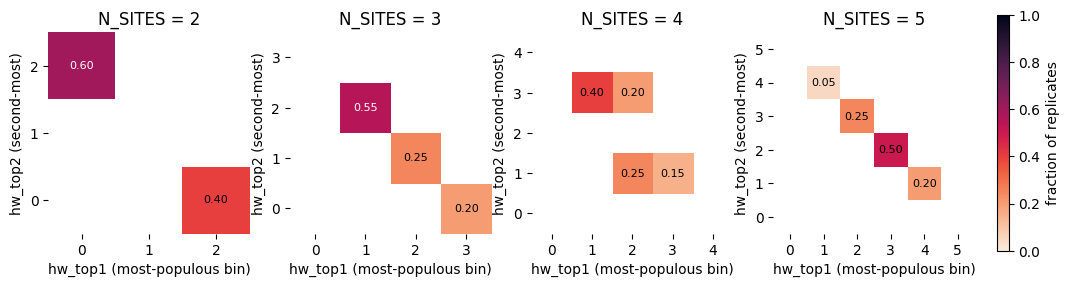

In [ ]:
n_sites_vals = sorted(frac_df["n_sites"].unique().tolist())
n_panels = len(n_sites_vals)

with tp.teed(
    plt.subplots,
    nrows=1,
    ncols=n_panels,
    figsize=(3.6 * n_panels, 3.6),
    squeeze=False,
    teeplot_outattrs={"a": "top2-hw-fraction"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (fig, axes):
    axes = axes[0]
    for _ax, _ns in zip(axes, n_sites_vals):
        _sub = frac_df[frac_df["n_sites"] == _ns]
        _hw_max = int(_ns)
        grid = np.full((_hw_max + 1, _hw_max + 1), np.nan)
        for _, _row in _sub.iterrows():
            grid[int(_row["hw_top2"]), int(_row["hw_top1"])] = float(
                _row["fraction"],
            )
        _masked = np.ma.masked_invalid(grid)
        _cmap = plt.get_cmap("rocket_r").copy()
        _cmap.set_bad("white")
        _im = _ax.imshow(
            _masked,
            origin="lower",
            cmap=_cmap,
            vmin=0.0,
            vmax=1.0,
            aspect="equal",
            interpolation="nearest",
        )
        for _i in range(_hw_max + 1):
            for _j in range(_hw_max + 1):
                if not np.ma.is_masked(_masked[_i, _j]):
                    _ax.text(
                        _j,
                        _i,
                        f"{_masked[_i, _j]:.2f}",
                        ha="center",
                        va="center",
                        fontsize=8,
                        color=(
                            "white" if _masked[_i, _j] > 0.5 else "black"
                        ),
                    )
        _ax.set_xticks(range(_hw_max + 1))
        _ax.set_yticks(range(_hw_max + 1))
        _ax.set_xlabel("hw_top1 (most-populous bin)")
        _ax.set_ylabel("hw_top2 (second-most)")
        _ax.set_title(f"N_SITES = {_ns}")
        sns.despine(ax=_ax, left=True, bottom=True)
    cbar = fig.colorbar(
        _im,
        ax=axes,
        pad=0.02,
        shrink=0.85,
        label="fraction of replicates",
    )
    _ = cbar

## Stacked Histogram by Top-2 Hamming-Weight Difference

Per-replicate **Hamming-weight gap** between the top-two end-state
bins, `hw_diff = |hw_top1 - hw_top2|`. A gap of 0 means the
replicate converged to a single dominant Hamming weight (all
sub-dominant cases share the same weight); a gap of 1 means the
second-most-populous bin sits one mutation away from the dominant
one; larger gaps mean the top-two cluster pair spans further
apart. We plot the **percent of replicates** (out of 20) at each
`hw_diff` value, stacked, per `N_SITES` condition.

percent of replicates by (n_sites, hw_diff):
hw_diff    0     1      2     3    4    5
n_sites                                  
2        0.0   0.0  100.0   0.0  0.0  0.0
3        0.0  80.0    0.0  20.0  0.0  0.0
4        0.0  45.0   55.0   0.0  0.0  0.0
5        0.0  75.0    0.0  25.0  0.0  0.0
teeplots/2026-05-27-founder-top2-convergence/a=top2-hw-diff-stacked-pct+viz=subplots+ext=.pdf
teeplots/2026-05-27-founder-top2-convergence/a=top2-hw-diff-stacked-pct+viz=subplots+ext=.png


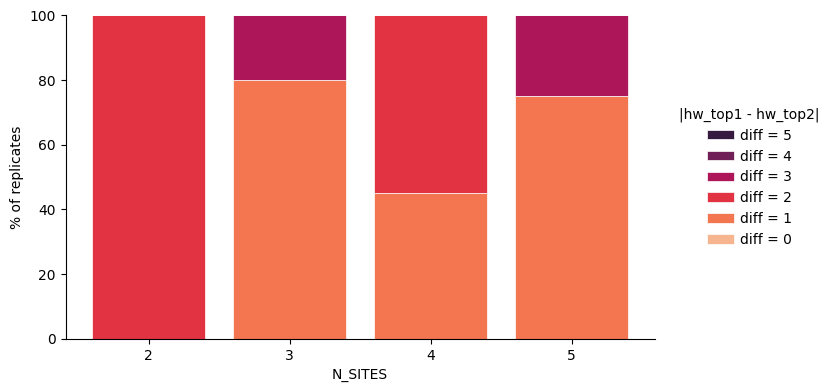

In [ ]:
# Possible Hamming-weight differences range from 0 to max(N_SITES)
# since each top bin's hw is in [0, N_SITES]. Set the hue order
# explicitly so stack ordering and the legend stay consistent
# across N_SITES conditions (smaller diffs at the bottom).
_max_n_sites = int(top2_df["n_sites"].max())
_hue_order = list(range(_max_n_sites + 1))

_diff_df = top2_df.assign(
    hw_diff=(top2_df["hw_top1"] - top2_df["hw_top2"]).abs(),
)
_totals = _diff_df.groupby("n_sites").size()
_pct_wide = (
    _diff_df.groupby(["n_sites", "hw_diff"]).size().unstack(fill_value=0)
)
_pct_wide = _pct_wide.div(_totals, axis=0).mul(100.0)
_pct_wide = _pct_wide.reindex(columns=_hue_order, fill_value=0.0)
print("percent of replicates by (n_sites, hw_diff):")
print(_pct_wide.round(1).to_string())

_palette = sns.color_palette("rocket_r", n_colors=len(_hue_order))
_n_conditions = len(_pct_wide.index)
_bar_x = np.arange(_n_conditions)

with tp.teed(
    plt.subplots,
    figsize=(1.4 * _n_conditions + 2.0, 4.2),
    teeplot_outattrs={"a": "top2-hw-diff-stacked-pct"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (_fig, _ax):
    _bottom = np.zeros(_n_conditions, dtype=float)
    for _hw_diff, _color in zip(_hue_order, _palette):
        _heights = _pct_wide[_hw_diff].to_numpy()
        _ax.bar(
            _bar_x,
            _heights,
            bottom=_bottom,
            color=_color,
            label=f"diff = {_hw_diff}",
            edgecolor="white",
            linewidth=0.5,
        )
        _bottom = _bottom + _heights
    _ax.set_xticks(_bar_x)
    _ax.set_xticklabels([str(int(_ns)) for _ns in _pct_wide.index])
    _ax.set_xlabel("N_SITES")
    _ax.set_ylabel("% of replicates")
    _ax.set_ylim(0, 100)
    # `reverse=True` (matplotlib >= 3.7) shows the largest hw_diff
    # entry at the top of the legend, matching the stack top-down.
    _handles, _labels = _ax.get_legend_handles_labels()
    _ax.legend(
        _handles[::-1],
        _labels[::-1],
        title="|hw_top1 - hw_top2|",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        handletextpad=0.4,
    )
    sns.despine(ax=_ax)

## Per-N_SITES Outcome Tables

One table per `N_SITES` condition listing every observed
end-state `(hw_top1, hw_top2)` pair with the percent of
replicates that converged there and the Hamming-weight gap
`hw_diff`. Rows are sorted by decreasing percent.

In [ ]:
_pct_df = frac_df.assign(
    hw_diff=(frac_df["hw_top1"] - frac_df["hw_top2"]).abs(),
    pct=(frac_df["fraction"] * 100.0).round(2),
)[
    [
        "n_sites",
        "hw_top1",
        "hw_top2",
        "hw_diff",
        "n_reps",
        "n_total",
        "pct",
    ]
]

_panels = []
for _ns in sorted(_pct_df["n_sites"].unique().tolist()):
    _sub = (
        _pct_df[_pct_df["n_sites"] == _ns]
        .sort_values("pct", ascending=False)
        .reset_index(drop=True)
    )
    print(f"\nN_SITES = {int(_ns)}")
    print(_sub.to_string(index=False))
    _panels.append(mo.md(f"### N_SITES = {int(_ns)}"))
    _panels.append(mo.ui.table(_sub, selection=None))
mo.vstack(_panels)


N_SITES = 2
 n_sites  hw_top1  hw_top2  hw_diff  n_reps  n_total  pct
       2        0        2        2      12       20 60.0
       2        2        0        2       8       20 40.0

N_SITES = 3
 n_sites  hw_top1  hw_top2  hw_diff  n_reps  n_total  pct
       3        1        2        1      11       20 55.0
       3        2        1        1       5       20 25.0
       3        3        0        3       4       20 20.0

N_SITES = 4
 n_sites  hw_top1  hw_top2  hw_diff  n_reps  n_total  pct
       4        1        3        2       8       20 40.0
       4        2        1        1       5       20 25.0
       4        2        3        1       4       20 20.0
       4        3        1        2       3       20 15.0

N_SITES = 5
 n_sites  hw_top1  hw_top2  hw_diff  n_reps  n_total  pct
       5        3        2        1      10       20 50.0
       5        2        3        1       5       20 25.0
       5        4        1        3       4       20 20.0
       5        1   

N_SITES = 2 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"n_sites\":2,\"hw_top1\":0,\"hw_top2\":2,\"hw_diff\":2,\"n_reps\":12,\"n_total\":20,\"pct\":60.0},{\"n_sites\":2,\"hw_top1\":2,\"hw_top2\":0,\"hw_diff\":2,\"n_reps\":8,\"n_total\":20,\"pct\":40.0}]"' data-total-rows='2' data-total-columns='7' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-field-types='[["n_sites",["integer","int64"]],["hw_top1",["integer","int64"]],["hw_top2",["integer","int64"]],["hw_diff",["integer","int64"]],["n_reps",["integer","int64"]],["n_total",["integer","int64"]],["pct",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> N_SITES = 3 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"n_sites\":3,\"hw_top1\":1,\"hw_top2\":2,\"hw_diff\":1,\"n_reps\":11,\"n_total\":20,\"pct\":55.0},{\"n_sites\":3,\"hw_top1\":2,\"hw_top2\":1,\"hw_diff\":1,\"n_reps\":5,\"n_total\":20,\"pct\":25.0},{\"n_sites\":3,\"hw_top1\":3,\"hw_top2\":0,\"hw_diff\":3,\"n_reps\":4,\"n_total\":20,\"pct\":20.0}]"' data-total-rows='3' data-total-columns='7' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-field-types='[["n_sites",["integer","int64"]],["hw_top1",["integer","int64"]],["hw_top2",["integer","int64"]],["hw_diff",["integer","int64"]],["n_reps",["integer","int64"]],["n_total",["integer","int64"]],["pct",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> N_SITES = 4 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"n_sites\":4,\"hw_top1\":1,\"hw_top2\":3,\"hw_diff\":2,\"n_reps\":8,\"n_total\":20,\"pct\":40.0},{\"n_sites\":4,\"hw_top1\":2,\"hw_top2\":1,\"hw_diff\":1,\"n_reps\":5,\"n_total\":20,\"pct\":25.0},{\"n_sites\":4,\"hw_top1\":2,\"hw_top2\":3,\"hw_diff\":1,\"n_reps\":4,\"n_total\":20,\"pct\":20.0},{\"n_sites\":4,\"hw_top1\":3,\"hw_top2\":1,\"hw_diff\":2,\"n_reps\":3,\"n_total\":20,\"pct\":15.0}]"' data-total-rows='4' data-total-columns='7' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-field-types='[["n_sites",["integer","int64"]],["hw_top1",["integer","int64"]],["hw_top2",["integer","int64"]],["hw_diff",["integer","int64"]],["n_reps",["integer","int64"]],["n_total",["integer","int64"]],["pct",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> N_SITES = 5 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"n_sites\":5,\"hw_top1\":3,\"hw_top2\":2,\"hw_diff\":1,\"n_reps\":10,\"n_total\":20,\"pct\":50.0},{\"n_sites\":5,\"hw_top1\":2,\"hw_top2\":3,\"hw_diff\":1,\"n_reps\":5,\"n_total\":20,\"pct\":25.0},{\"n_sites\":5,\"hw_top1\":4,\"hw_top2\":1,\"hw_diff\":3,\"n_reps\":4,\"n_total\":20,\"pct\":20.0},{\"n_sites\":5,\"hw_top1\":1,\"hw_top2\":4,\"hw_diff\":3,\"n_reps\":1,\"n_total\":20,\"pct\":5.0}]"' data-total-rows='4' data-total-columns='7' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-field-types='[["n_sites",["integer","int64"]],["hw_top1",["integer","int64"]],["hw_top2",["integer","int64"]],["hw_diff",["integer","int64"]],["n_reps",["integer","int64"]],["n_total",["integer","int

## Stacked Histogram by Top-1 Hamming Offset

For each replicate, take the **single most-populous** Hamming-
weight bin at the final step (`hw_top1`) and report its
**hamming offset** `min(hw, N_SITES - hw)`: the smaller of the
two distances from `hw` to the nearest "extreme" Hamming weight
(`0` = pure founder/wildtype, `N_SITES` = its bitwise
complement). An offset of `0` means the dominant strain at end
is at one of the two extremes; an offset of `floor(N_SITES /
2)` means it sits as far from either extreme as the bit budget
allows. Plot the **percent of replicates** at each offset value,
stacked per `N_SITES`, with a fixed hue order across panels.

percent of replicates by (n_sites, hamming_offset):
hamming_offset      0     1     2
n_sites                          
2               100.0   0.0   0.0
3                20.0  80.0   0.0
4                 0.0  55.0  45.0
5                 0.0  25.0  75.0
teeplots/2026-05-27-founder-top2-convergence/a=top1-hamming-offset-stacked-pct+viz=subplots+ext=.pdf
teeplots/2026-05-27-founder-top2-convergence/a=top1-hamming-offset-stacked-pct+viz=subplots+ext=.png


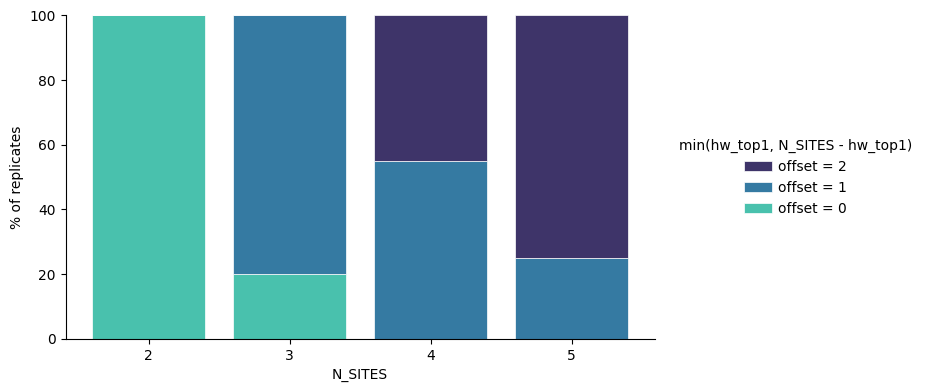

In [ ]:
_offset_df = top2_df.assign(
    hamming_offset=np.minimum(
        top2_df["hw_top1"],
        top2_df["n_sites"] - top2_df["hw_top1"],
    ),
)
_max_n_sites = int(top2_df["n_sites"].max())
_max_offset = _max_n_sites // 2
_hue_order = list(range(_max_offset + 1))

_totals = _offset_df.groupby("n_sites").size()
_pct_wide = (
    _offset_df.groupby(["n_sites", "hamming_offset"])
    .size()
    .unstack(fill_value=0)
)
_pct_wide = _pct_wide.div(_totals, axis=0).mul(100.0)
_pct_wide = _pct_wide.reindex(columns=_hue_order, fill_value=0.0)
print("percent of replicates by (n_sites, hamming_offset):")
print(_pct_wide.round(1).to_string())

_palette = sns.color_palette("mako_r", n_colors=len(_hue_order))
_n_conditions = len(_pct_wide.index)
_bar_x = np.arange(_n_conditions)

with tp.teed(
    plt.subplots,
    figsize=(1.4 * _n_conditions + 2.0, 4.2),
    teeplot_outattrs={"a": "top1-hamming-offset-stacked-pct"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (_fig, _ax):
    _bottom = np.zeros(_n_conditions, dtype=float)
    for _off, _color in zip(_hue_order, _palette):
        _heights = _pct_wide[_off].to_numpy()
        _ax.bar(
            _bar_x,
            _heights,
            bottom=_bottom,
            color=_color,
            label=f"offset = {_off}",
            edgecolor="white",
            linewidth=0.5,
        )
        _bottom = _bottom + _heights
    _ax.set_xticks(_bar_x)
    _ax.set_xticklabels([str(int(_ns)) for _ns in _pct_wide.index])
    _ax.set_xlabel("N_SITES")
    _ax.set_ylabel("% of replicates")
    _ax.set_ylim(0, 100)
    _handles, _labels = _ax.get_legend_handles_labels()
    _ax.legend(
        _handles[::-1],
        _labels[::-1],
        title="min(hw_top1, N_SITES - hw_top1)",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        handletextpad=0.4,
    )
    sns.despine(ax=_ax)

## Per-N_SITES Top-1 Hamming-Offset Tables

One table per `N_SITES` condition listing each observed value of
the top-1 Hamming weight `hw_top1`, its `hamming_offset =
min(hw_top1, N_SITES - hw_top1)`, the number of replicates at
that value, and the percent of replicates. Sorted by descending
percent.

In [ ]:
_offset_full = top2_df.assign(
    hamming_offset=np.minimum(
        top2_df["hw_top1"],
        top2_df["n_sites"] - top2_df["hw_top1"],
    ),
)
_counts = (
    _offset_full.groupby(["n_sites", "hw_top1", "hamming_offset"])
    .size()
    .rename("n_reps")
    .reset_index()
)
_totals = (
    _offset_full.groupby("n_sites").size().rename("n_total").reset_index()
)
_offset_pct = _counts.merge(_totals, on="n_sites")
_offset_pct["pct"] = (
    _offset_pct["n_reps"] / _offset_pct["n_total"] * 100.0
).round(2)

_panels = []
for _ns in sorted(_offset_pct["n_sites"].unique().tolist()):
    _sub = (
        _offset_pct[_offset_pct["n_sites"] == _ns]
        .sort_values("pct", ascending=False)
        .reset_index(drop=True)
    )
    print(f"\nN_SITES = {int(_ns)}")
    print(_sub.to_string(index=False))
    _panels.append(mo.md(f"### N_SITES = {int(_ns)}"))
    _panels.append(mo.ui.table(_sub, selection=None))
mo.vstack(_panels)


N_SITES = 2
 n_sites  hw_top1  hamming_offset  n_reps  n_total  pct
       2        0               0      12       20 60.0
       2        2               0       8       20 40.0

N_SITES = 3
 n_sites  hw_top1  hamming_offset  n_reps  n_total  pct
       3        1               1      11       20 55.0
       3        2               1       5       20 25.0
       3        3               0       4       20 20.0

N_SITES = 4
 n_sites  hw_top1  hamming_offset  n_reps  n_total  pct
       4        2               2       9       20 45.0
       4        1               1       8       20 40.0
       4        3               1       3       20 15.0

N_SITES = 5
 n_sites  hw_top1  hamming_offset  n_reps  n_total  pct
       5        3               2      10       20 50.0
       5        2               2       5       20 25.0
       5        4               1       4       20 20.0
       5        1               1       1       20  5.0


N_SITES = 2 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"n_sites\":2,\"hw_top1\":0,\"hamming_offset\":0,\"n_reps\":12,\"n_total\":20,\"pct\":60.0},{\"n_sites\":2,\"hw_top1\":2,\"hamming_offset\":0,\"n_reps\":8,\"n_total\":20,\"pct\":40.0}]"' data-total-rows='2' data-total-columns='6' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-field-types='[["n_sites",["integer","int64"]],["hw_top1",["integer","int64"]],["hamming_offset",["integer","int64"]],["n_reps",["integer","int64"]],["n_total",["integer","int64"]],["pct",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> N_SITES = 3 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"n_sites\":3,\"hw_top1\":1,\"hamming_offset\":1,\"n_reps\":11,\"n_total\":20,\"pct\":55.0},{\"n_sites\":3,\"hw_top1\":2,\"hamming_offset\":1,\"n_reps\":5,\"n_total\":20,\"pct\":25.0},{\"n_sites\":3,\"hw_top1\":3,\"hamming_offset\":0,\"n_reps\":4,\"n_total\":20,\"pct\":20.0}]"' data-total-rows='3' data-total-columns='6' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-field-types='[["n_sites",["integer","int64"]],["hw_top1",["integer","int64"]],["hamming_offset",["integer","int64"]],["n_reps",["integer","int64"]],["n_total",["integer","int64"]],["pct",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> N_SITES = 4 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"n_sites\":4,\"hw_top1\":2,\"hamming_offset\":2,\"n_reps\":9,\"n_total\":20,\"pct\":45.0},{\"n_sites\":4,\"hw_top1\":1,\"hamming_offset\":1,\"n_reps\":8,\"n_total\":20,\"pct\":40.0},{\"n_sites\":4,\"hw_top1\":3,\"hamming_offset\":1,\"n_reps\":3,\"n_total\":20,\"pct\":15.0}]"' data-total-rows='3' data-total-columns='6' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-field-types='[["n_sites",["integer","int64"]],["hw_top1",["integer","int64"]],["hamming_offset",["integer","int64"]],["n_reps",["integer","int64"]],["n_total",["integer","int64"]],["pct",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> N_SITES = 5 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"n_sites\":5,\"hw_top1\":3,\"hamming_offset\":2,\"n_reps\":10,\"n_total\":20,\"pct\":50.0},{\"n_sites\":5,\"hw_top1\":2,\"hamming_offset\":2,\"n_reps\":5,\"n_total\":20,\"pct\":25.0},{\"n_sites\":5,\"hw_top1\":4,\"hamming_offset\":1,\"n_reps\":4,\"n_total\":20,\"pct\":20.0},{\"n_sites\":5,\"hw_top1\":1,\"hamming_offset\":1,\"n_reps\":1,\"n_total\":20,\"pct\":5.0}]"' data-total-rows='4' data-total-columns='6' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-field-types='[["n_sites",["integer","int64"]],["hw_top1",["integer","int64"]],["hamming_offset",["integer","int64"]],["n_reps",["integer","int64"]],["n_total",["integer","int64"]],["pct",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-

## First Appearance of Max-Hamming-Weight Strain vs. Outcome

For each replicate, find the **first simulation step** at which
any case sits at the maximum Hamming weight `hw == N_SITES` ---
the all-ones `1111...` strain, the bitwise complement of the
founder. Replicates where the max-hw strain never appears are
**censored to the simulation horizon** `N_STEPS` (treated as if
it appeared at the very last step), per the analysis spec.

Plot the resulting first-appearance step against the end-state
outcome `hw_top1` (most-populous Hamming weight at the final
step) as a per-`N_SITES` `sns.lmplot` with a fitted regression
line in each panel, and run a Spearman rank correlation per
condition (plus pooled) to test whether earlier emergence of
the all-ones strain predicts a higher end-state Hamming weight.

In [ ]:
# Earliest step at which the all-ones strain (hw == n_sites) has
# any circulating cases, per replicate.
_max_hw_mask = (hw_df["hw"] == hw_df["n_sites"]) & (hw_df["n_cases"] > 0)
_first = (
    hw_df[_max_hw_mask]
    .groupby("replicate_uid")["Step"]
    .min()
    .rename("first_max_hw_step")
)

_per_rep_meta = (
    hw_df[["replicate_uid", "n_steps"]]
    .drop_duplicates()
    .set_index("replicate_uid")["n_steps"]
)

appearance_df = (
    top2_df[["replicate_uid", "n_sites", "hw_top1"]]
    .merge(_first, on="replicate_uid", how="left")
    .merge(_per_rep_meta, on="replicate_uid", how="left")
)
# Censor non-appearance to the simulation horizon N_STEPS.
appearance_df["censored"] = appearance_df["first_max_hw_step"].isna()
appearance_df["first_max_hw_step"] = (
    appearance_df["first_max_hw_step"]
    .fillna(appearance_df["n_steps"])
    .astype(int)
)
# Outcome metric: hamming offset of the end-state dominant strain
# to the nearest extreme (0 = founder, N_SITES = all-ones).
appearance_df["hamming_offset"] = np.minimum(
    appearance_df["hw_top1"],
    appearance_df["n_sites"] - appearance_df["hw_top1"],
)

print(
    "censored (never appeared) replicates: "
    f"{int(appearance_df['censored'].sum())} / {len(appearance_df)}"
)
print("censored per n_sites:")
print(appearance_df.groupby("n_sites")["censored"].sum())
print(appearance_df.head().to_string(index=False))

censored (never appeared) replicates: 0 / 80
censored per n_sites:
n_sites
2    0
3    0
4    0
5    0
Name: censored, dtype: int64
                   replicate_uid  n_sites  hw_top1  first_max_hw_step  n_steps  censored  hamming_offset
09ca074222a246728839923cdd64355e        2        0                 75     5000     False               0
0bcb0434d8204ec58669ef1f517608b4        2        2                 62     5000     False               0
133bdfa52c1b400d9e0c3d78b7c0b8eb        3        1                 82     5000     False               1
15ab965cedfa4fdba341affdb431795e        4        1                334     5000     False               1
19e016723c224124bd2f448b608ae593        3        3                140     5000     False               0


teeplots/2026-05-27-founder-top2-convergence/a=first-max-hw-vs-hamming-offset+col=n-sites+viz=lmplot+x=first-max-hw-step+y=hamming-offset+ext=.pdf
teeplots/2026-05-27-founder-top2-convergence/a=first-max-hw-vs-hamming-offset+col=n-sites+viz=lmplot+x=first-max-hw-step+y=hamming-offset+ext=.png


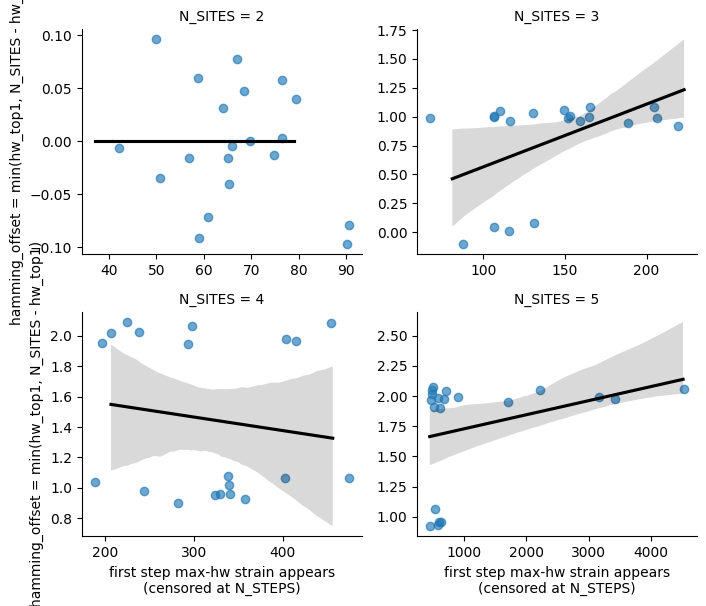

In [ ]:
with tp.teed(
    sns.lmplot,
    data=appearance_df,
    x="first_max_hw_step",
    y="hamming_offset",
    col="n_sites",
    col_wrap=2,
    height=3.0,
    aspect=1.2,
    x_jitter=20.0,
    y_jitter=0.1,
    scatter_kws={"alpha": 0.65, "s": 36},
    line_kws={"color": "black"},
    facet_kws={"sharex": False, "sharey": False},
    teeplot_outattrs={"a": "first-max-hw-vs-hamming-offset"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _g.set_axis_labels(
        "first step max-hw strain appears\n(censored at N_STEPS)",
        "hamming_offset = min(hw_top1, N_SITES - hw_top1)",
    )
    _g.set_titles("N_SITES = {col_name}")
    for _ax in _g.axes.flat:
        sns.despine(ax=_ax)

In [ ]:
_rows = []
for _ns in sorted(appearance_df["n_sites"].unique().tolist()):
    _sub = appearance_df[appearance_df["n_sites"] == _ns]
    _x = _sub["first_max_hw_step"].to_numpy()
    _y = _sub["hamming_offset"].to_numpy()
    _rho, _pval = sps.spearmanr(_x, _y)
    _rows.append(
        {
            "n_sites": str(int(_ns)),
            "n": len(_sub),
            "n_censored": int(_sub["censored"].sum()),
            "spearman_rho": round(float(_rho), 3),
            "p_value": float(_pval),
        },
    )
_rho_all, _pval_all = sps.spearmanr(
    appearance_df["first_max_hw_step"],
    appearance_df["hamming_offset"],
)
_rows.append(
    {
        "n_sites": "pooled",
        "n": len(appearance_df),
        "n_censored": int(appearance_df["censored"].sum()),
        "spearman_rho": round(float(_rho_all), 3),
        "p_value": float(_pval_all),
    },
)
stat_df = pd.DataFrame(_rows)
print(
    "Spearman rank correlation: first_max_hw_step vs hamming_offset "
    "(censored at N_STEPS for non-appearance):",
)
print(stat_df.to_string(index=False))
mo.ui.table(stat_df, selection=None)

/tmp/marimo_4699/__marimo__cell_ecfG_.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _rho, _pval = sps.spearmanr(_x, _y)


Spearman rank correlation: first_max_hw_step vs hamming_offset (censored at N_STEPS for non-appearance):
n_sites  n  n_censored  spearman_rho      p_value
      2 20           0           NaN          NaN
      3 20           0         0.520 1.864027e-02
      4 20           0        -0.148 5.330568e-01
      5 20           0         0.270 2.490060e-01
 pooled 80           0         0.844 9.293737e-23


,n_sites,n,n_censored,spearman_rho,p_value
0,2,20,0,NaN,NaN
1,3,20,0,0.520,1.864027e-02
2,4,20,0,-0.148,5.330568e-01
3,5,20,0,0.270,2.490060e-01
4,pooled,80,0,0.844,9.293737e-23
